In [26]:
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
df = pd.read_excel("CountMe_Student_Performance_2026.xlsx")
df

,Student_ID,Student_Name,Grade,Gender,Subject,Pre_Test,Mid_Test,Post_Test,Attendance (%),Homework Completion (%),Study_Hours_Per_Week,Improvement,Performance,Learning_Outcome
0,S001,Aditya,10,M,Mathematics,62,72,81,100,100,4,19,Excellent,Very Good
1,S002,Alya,10,F,Mathematics,71,80,89,100,100,4,18,Excellent,Very Good
2,S003,Bintang,10,M,Mathematics,58,69,77,92,90,4,19,Excellent,Good
3,S004,Natalia,10,F,Mathematics,75,83,91,100,100,4,16,Excellent,Outstanding
4,S005,Daffa,10,M,Mathematics,64,74,82,96,95,4,18,Excellent,Very Good
5,S006,Elvin,10,F,Mathematics,81,87,95,100,100,4,14,Good,Outstanding
6,S007,Putri,10,M,Mathematics,69,78,86,96,95,4,17,Excellent,Very Good
7,S008,Gita Maharani,10,F,Mathematics,67,76,84,92,90,4,17,Excellent,Very Good
8,S009,Bulan,10,M,Mathematics,60,70,79,88,85,4,19,Excellent,Good
9,S010,Intan,10,F,Mathematics,78,86,94,100,100,4,16,Excellent,Outstanding


In [ ]:
df.head()

In [ ]:
df.info()

In [ ]:
df.describe()

In [ ]:
df.shape

In [11]:
df.columns

Index(['Student_ID', 'Student_Name', 'Grade', 'Gender', 'Subject', 'Pre_Test',
       'Mid_Test', 'Post_Test', 'Attendance (%)', 'Homework Completion (%)',
       'Study_Hours_Per_Week', 'Improvement', 'Performance',
       'Learning_Outcome'],
      dtype='object')

Data Cleaning

In [12]:
df.isnull().sum()

,0
Student_ID,0
Student_Name,0
Grade,0
Gender,0
Subject,0
Pre_Test,0
Mid_Test,0
Post_Test,0
Attendance (%),0
Homework Completion (%),0


In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df.dtypes

,0
Student_ID,object
Student_Name,object
Grade,int64
Gender,object
Subject,object
Pre_Test,int64
Mid_Test,int64
Post_Test,int64
Attendance (%),int64
Homework Completion (%),int64


Feature Engineering

In [15]:
df["Improvement"] = df["Post_Test"] - df["Pre_Test"]

In [16]:
def improvement(x):
    if x >= 15:
        return "Excellent"
    elif x >= 10:
        return "Good"
    else:
        return "Needs Improvement"

df["Performance"] = df["Improvement"].apply(improvement)

Exploratory Data Analysis (EDA)

In [17]:
df[["Pre_Test","Mid_Test","Post_Test"]].mean()

,0
Pre_Test,70.800000
Mid_Test,79.700000
Post_Test,87.733333


In [18]:
df["Post_Test"].max()

97

In [19]:
df["Post_Test"].min()

77

In [20]:
df["Attendance (%)"].mean()

np.float64(96.8)

In [21]:
df["Grade"].value_counts()

,count
Grade,
10,10
11,10
12,10


In [22]:
df["Performance"].value_counts()

,count
Performance,
Excellent,27
Good,3


In [23]:
df.nlargest(10,"Improvement")

,Student_ID,Student_Name,Grade,Gender,Subject,Pre_Test,Mid_Test,Post_Test,Attendance (%),Homework Completion (%),Study_Hours_Per_Week,Improvement,Performance,Learning_Outcome
0,S001,Aditya,10,M,Mathematics,62,72,81,100,100,4,19,Excellent,Very Good
2,S003,Bintang,10,M,Mathematics,58,69,77,92,90,4,19,Excellent,Good
8,S009,Bulan,10,M,Mathematics,60,70,79,88,85,4,19,Excellent,Good
10,S011,Jovan,11,M,Mathematics,65,75,84,96,95,4,19,Excellent,Very Good
16,S017,Putra Aditya,11,M,Mathematics,61,71,80,88,85,4,19,Excellent,Very Good
24,S025,Yoga Pradana,12,M,Mathematics,62,72,81,92,90,4,19,Excellent,Very Good
1,S002,Alya,10,F,Mathematics,71,80,89,100,100,4,18,Excellent,Very Good
4,S005,Daffa,10,M,Mathematics,64,74,82,96,95,4,18,Excellent,Very Good
12,S013,Lukman,11,M,Mathematics,63,73,81,92,90,4,18,Excellent,Very Good
20,S021,Teguh,12,M,Mathematics,66,76,84,96,95,4,18,Excellent,Very Good


VISUALISASI

Grafik 1 Distribusi Nilai

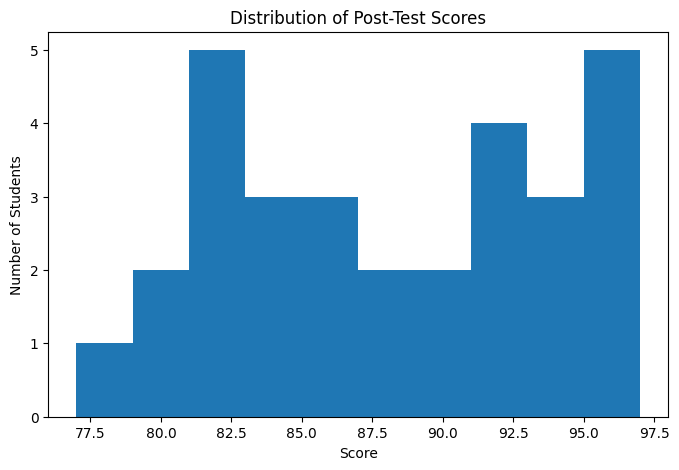

In [27]:
plt.figure(figsize=(8,5))
plt.hist(df["Post_Test"])
plt.title("Distribution of Post-Test Scores")
plt.xlabel("Score")
plt.ylabel("Number of Students")
plt.show()

Grafik 2 Kehadiran

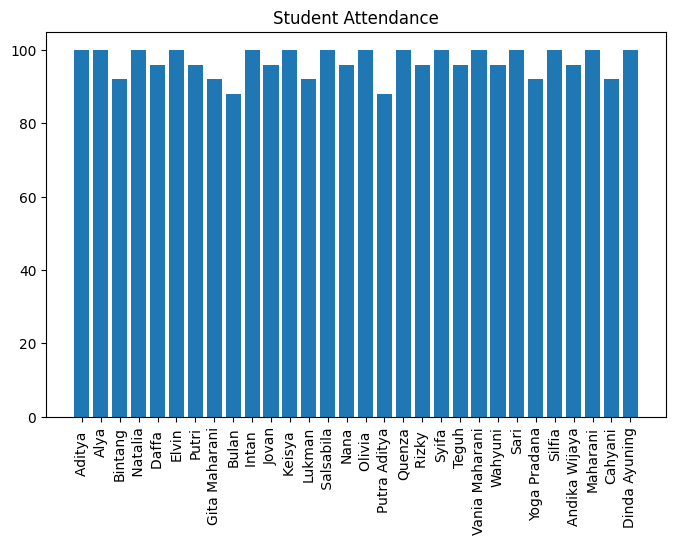

In [28]:
plt.figure(figsize=(8,5))
plt.bar(df["Student_Name"],df["Attendance (%)"])
plt.xticks(rotation=90)
plt.title("Student Attendance")
plt.show()

Grafik 3 Distribusi Kelas

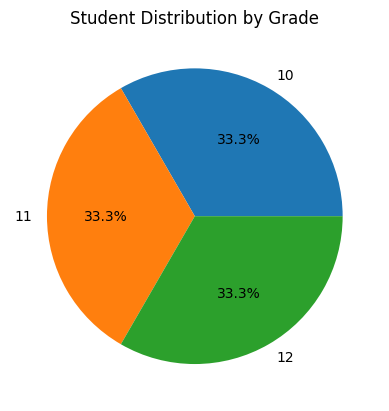

In [29]:
df["Grade"].value_counts().plot(kind="pie",autopct="%1.1f%%")
plt.ylabel("")
plt.title("Student Distribution by Grade")
plt.show()

Grafik 4 Top 10 Improvement

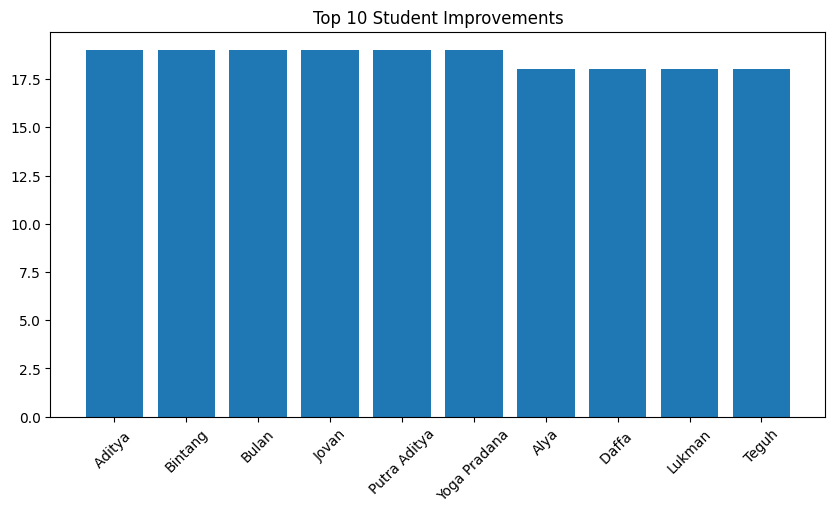

In [30]:
top=df.nlargest(10,"Improvement")

plt.figure(figsize=(10,5))
plt.bar(top["Student_Name"],top["Improvement"])
plt.xticks(rotation=45)
plt.title("Top 10 Student Improvements")
plt.show()

Grafik 5 Perbandingan Nilai

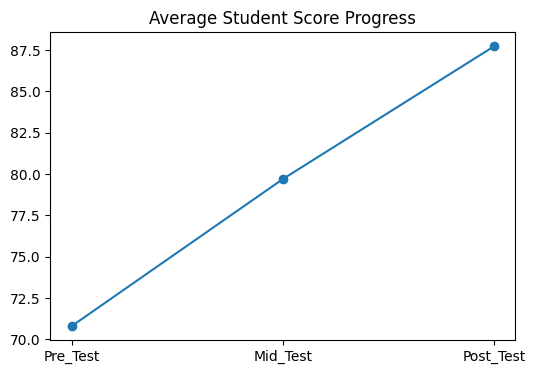

In [31]:
avg=df[["Pre_Test","Mid_Test","Post_Test"]].mean()

plt.figure(figsize=(6,4))
plt.plot(avg.index,avg.values,marker="o")
plt.title("Average Student Score Progress")
plt.show()

KESIMPULAN

Berdasarkan hasil analisis yang muncul:
1. Nilai rata-rata siswa meningkat dari Pre-Test ke Post-Test, menunjukkan adanya perkembangan setelah mengikuti program bimbingan belajar.
2. Mayoritas siswa memiliki tingkat kehadiran yang tinggi, yang mendukung proses pembelajaran yang konsisten.
3. Sebagian besar siswa menyelesaikan tugas dengan baik, mengindikasikan keterlibatan yang positif selama program.
4. Beberapa siswa menunjukkan peningkatan yang lebih rendah sehingga dapat menjadi prioritas untuk pendampingan tambahan.







